In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
mpl.rcParams['font.family'] = 'Arial'


In [2]:
#Reads all radial.txt files of a given genotype and returns a list of dataframes, 
#each dataframe originates from an individual file

def read_genotype_dfs(radialResults_folder, genotype):

    genotype_dfs = []

    for filename in os.listdir(radialResults_folder):
        if filename.endswith("_radial.txt") and genotype in filename:
            print(filename)

            radialfile = os.path.join(radialResults_folder, filename)
            radial_df = pd.read_csv(radialfile, delimiter='\t')
            genotype_dfs.append(radial_df)

    return(genotype_dfs)
  
# radialResults_folder = 'D:/Augusto/Images/NSPARC/FISH-AprMay2025/Analysis/RadialResults' #avoid writing a dash / at the end
# genotype = "HoxA"
# HoxA_dfs = read_genotype_dfs(radialResults_folder, genotype)
      

In [3]:
#Reads list of pandas dataframes generated by function read_genotype_dfs
#and extracts expression and radius columns

def readExpAndRadius(genotype_dfs, radius, mean_max):
        
    radius_type = str(radius)+mean_max
    radius_column = pd.concat([df[radius_type] for df in genotype_dfs], ignore_index=True)
    
    exp_mean = pd.concat([df["expmean"] for df in genotype_dfs], ignore_index=True)
    
    exp_median = pd.concat([df["expmedian"] for df in genotype_dfs], ignore_index=True)
    
    perc20 = str(radius)+"perc20"
    perc20_column = pd.concat([df[perc20] for df in genotype_dfs], ignore_index=True)
        
    return(exp_mean, exp_median, radius_column, perc20_column)




In [4]:
def readExpAndRadius_dapi(genotype_dfs, radius, mean_max):
    
    radius_type = str(radius)+"dapi"+mean_max
    radius_column = pd.concat([df[radius_type] for df in genotype_dfs], ignore_index=True)
    
    exp_mean = pd.concat([df["expmean"] for df in genotype_dfs], ignore_index=True)
    
    exp_median = pd.concat([df["expmedian"] for df in genotype_dfs], ignore_index=True)
    
    perc20 = str(radius)+"dapiperc20"
    perc20_column = pd.concat([df[perc20] for df in genotype_dfs], ignore_index=True)
    
    return(exp_mean, exp_median, radius_column, perc20_column)

In [5]:
#Sort cells by expression bins
#expressionBins take a np array with the edges of bins
#(e.g. exp_bins = np.array([0, 10, 20, 30, 200])  # bins: [0–10), [10–20), [20–30), (300, 200))
#and a expression bin to be sorted (e.g. meanexp_HoxB)

#It returns a dictionary indices_in_bins with the indices sorted by their bin 

def expressionBins(exp_vector, exp_bins):
    
    # Assign each value in vec to a bin
    bin_indices = np.digitize(exp_vector, exp_bins)  # gives bin number for each element

    # Collect indices of vec in each bin
    indices_in_bins = {i: np.where(bin_indices == i)[0] for i in range(1, len(exp_bins))}
    # i starts at 1 because digitize bins are 1-based
        
    #print("Vector:", exp_vector)
    #print("Bin indices:", bin_indices)
    #print("Indices in bins:", indices_in_bins)
    #print(indices_in_bins.get(1))
    
    return(indices_in_bins)

####Testing code
# Define bin edges
# exp_bins = np.array([0, 10, 20, 30, 200])  # bins: [0–3), [3–6), [6–10)
# indices_in_bins_HoxB = expressionBins(meanexp_HoxB, exp_bins)

# indices_in_bins_HoxB.get(1)

In [6]:
radialResults_folder = 'D:/Augusto/Images/NSPARC/FISH-Jun2025/Analysis/RadialResults' #avoid writing a dash / at the end

genotype_HoxA = "HoxA"
genotype_HoxB = "HoxB"
genotype_HoxD = "HoxD"

genotype_MUC4 = "MUC4"
genotype_TNF = "TNF"
genotype_MYC = "MYC"


In [7]:
HoxA_dfs = read_genotype_dfs(radialResults_folder, genotype_HoxA)
meanexp_HoxA, medianexp_HoxA, HoxA_100, HoxA_100perc20 = readExpAndRadius(HoxA_dfs, 100, "max")
meanexp_HoxA, medianexp_HoxA, HoxA_200, HoxA_200perc20 = readExpAndRadius(HoxA_dfs, 200, "max")
meanexp_HoxA, medianexp_HoxA, HoxA_300, HoxA_300perc20 = readExpAndRadius(HoxA_dfs, 300, "max")
meanexp_HoxA, medianexp_HoxA, HoxA_400, HoxA_400perc20 = readExpAndRadius(HoxA_dfs, 400, "max")
meanexp_HoxA, medianexp_HoxA, HoxA_800, HoxA_800perc20 = readExpAndRadius(HoxA_dfs, 800, "max")
meanexp_HoxA, medianexp_HoxA, HoxA_1000, HoxA_1000perc20 = readExpAndRadius(HoxA_dfs, 1000, "max")


20250429_HEK293FT-HoxA-NKF_0000_radial.txt
20250429_HEK293FT-HoxA-NKF_0001_radial.txt
20250429_HEK293FT-HoxA-NKF_0002_radial.txt
20250627_HEK293FT-HoxA-NKF-DMSO_0000_radial.txt
20250627_HEK293FT-HoxA-NKF-DMSO_0001_radial.txt
20250627_HEK293FT-HoxA-NKF-DMSO_0002_radial.txt


In [8]:
HoxB_dfs = read_genotype_dfs(radialResults_folder, genotype_HoxB)
meanexp_HoxB, medianexp_HoxB, HoxB_100, HoxB_100perc20 = readExpAndRadius(HoxB_dfs, 100, "max")
meanexp_HoxB, medianexp_HoxB, HoxB_200, HoxB_200perc20 = readExpAndRadius(HoxB_dfs, 200, "max")
meanexp_HoxB, medianexp_HoxB, HoxB_300, HoxB_300perc20 = readExpAndRadius(HoxB_dfs, 300, "max")
meanexp_HoxB, medianexp_HoxB, HoxB_400, HoxB_400perc20 = readExpAndRadius(HoxB_dfs, 400, "max")
meanexp_HoxB, medianexp_HoxB, HoxB_800, HoxB_800perc20 = readExpAndRadius(HoxB_dfs, 800, "max")
meanexp_HoxB, medianexp_HoxB, HoxB_1000, HoxB_1000perc20 = readExpAndRadius(HoxB_dfs, 1000, "max")


20250508_HEK293FT-HoxB-NKF_0000_radial.txt
20250508_HEK293FT-HoxB-NKF_0001_radial.txt
20250508_HEK293FT-HoxB-NKF_0002_radial.txt
20250508_HEK293FT-HoxB-NKF_0003_radial.txt
20250627_HEK293FT-HoxB-NKF-DMSO_0000_radial.txt
20250627_HEK293FT-HoxB-NKF-DMSO_0001_radial.txt
20250627_HEK293FT-HoxB-NKF-DMSO_0002_radial.txt


In [9]:
HoxD_dfs = read_genotype_dfs(radialResults_folder, genotype_HoxD)
meanexp_HoxD, medianexp_HoxD, HoxD_100, HoxD_100perc20 = readExpAndRadius(HoxD_dfs, 100, "max")
meanexp_HoxD, medianexp_HoxD, HoxD_200, HoxD_200perc20 = readExpAndRadius(HoxD_dfs, 200, "max")
meanexp_HoxD, medianexp_HoxD, HoxD_300, HoxD_300perc20 = readExpAndRadius(HoxD_dfs, 300, "max")
meanexp_HoxD, medianexp_HoxD, HoxD_400, HoxD_400perc20 = readExpAndRadius(HoxD_dfs, 400, "max")
meanexp_HoxD, medianexp_HoxD, HoxD_800, HoxD_800perc20 = readExpAndRadius(HoxD_dfs, 800, "max")
meanexp_HoxD, medianexp_HoxD, HoxD_1000, HoxD_1000perc20 = readExpAndRadius(HoxD_dfs, 1000, "max")


20250508_HEK293FT-HoxD-NKF_0000_radial.txt
20250508_HEK293FT-HoxD-NKF_0001_radial.txt
20250508_HEK293FT-HoxD-NKF_0002_radial.txt
20250508_HEK293FT-HoxD-NKF_0003_radial.txt


In [10]:
MUC4_dfs = read_genotype_dfs(radialResults_folder, genotype_MUC4)
meanexp_MUC4, medianexp_MUC4, MUC4_100, MUC4_100perc20 = readExpAndRadius(MUC4_dfs, 100, "max")
meanexp_MUC4, medianexp_MUC4, MUC4_200, MUC4_200perc20 = readExpAndRadius(MUC4_dfs, 200, "max")
meanexp_MUC4, medianexp_MUC4, MUC4_300, MUC4_300perc20 = readExpAndRadius(MUC4_dfs, 300, "max")
meanexp_MUC4, medianexp_MUC4, MUC4_400, MUC4_400perc20 = readExpAndRadius(MUC4_dfs, 400, "max")
meanexp_MUC4, medianexp_MUC4, MUC4_800, MUC4_800perc20 = readExpAndRadius(MUC4_dfs, 800, "max")
meanexp_MUC4, medianexp_MUC4, MUC4_1000, MUC4_1000perc20 = readExpAndRadius(MUC4_dfs, 1000, "max")


20250429_HEK293FT-MUC4-NKF_0000_radial.txt
20250429_HEK293FT-MUC4-NKF_0001_radial.txt
20250429_HEK293FT-MUC4-NKF_0002_radial.txt


In [11]:
TNF_dfs = read_genotype_dfs(radialResults_folder, genotype_TNF)
meanexp_TNF, medianexp_TNF, TNF_100, TNF_100perc20 = readExpAndRadius(TNF_dfs, 100, "max")
meanexp_TNF, medianexp_TNF, TNF_200, TNF_200perc20 = readExpAndRadius(TNF_dfs, 200, "max")
meanexp_TNF, medianexp_TNF, TNF_300, TNF_300perc20 = readExpAndRadius(TNF_dfs, 300, "max")
meanexp_TNF, medianexp_TNF, TNF_400, TNF_400perc20 = readExpAndRadius(TNF_dfs, 400, "max")
meanexp_TNF, medianexp_TNF, TNF_800, TNF_800perc20 = readExpAndRadius(TNF_dfs, 800, "max")
meanexp_TNF, medianexp_TNF, TNF_1000, TNF_1000perc20 = readExpAndRadius(TNF_dfs, 1000, "max")


20250429_HEK293FT-TNF-NKF_0000_radial.txt
20250429_HEK293FT-TNF-NKF_0001_radial.txt
20250429_HEK293FT-TNF-NKF_0002_radial.txt
20250429_HEK293FT-TNF-NKF_0003_radial.txt
20250727_HEK293FT-TNF-NKF-DMSO_0000_radial.txt
20250727_HEK293FT-TNF-NKF-DMSO_0001_radial.txt
20250727_HEK293FT-TNF-NKF-DMSO_0002_radial.txt


In [12]:
MYC_dfs = read_genotype_dfs(radialResults_folder, genotype_MYC)
meanexp_MYC, medianexp_MYC, MYC_100, MYC_100perc20 = readExpAndRadius(MYC_dfs, 100, "max")
meanexp_MYC, medianexp_MYC, MYC_200, MYC_200perc20 = readExpAndRadius(MYC_dfs, 200, "max")
meanexp_MYC, medianexp_MYC, MYC_300, MYC_300perc20 = readExpAndRadius(MYC_dfs, 300, "max")
meanexp_MYC, medianexp_MYC, MYC_400, MYC_400perc20 = readExpAndRadius(MYC_dfs, 400, "max")
meanexp_MYC, medianexp_MYC, MYC_800, MYC_800perc20 = readExpAndRadius(MYC_dfs, 800, "max")
meanexp_MYC, medianexp_MYC, MYC_1000, MYC_1000perc20 = readExpAndRadius(MYC_dfs, 1000, "max")


20250429_HEK293FT-MYC-NKF_0000_radial.txt
20250429_HEK293FT-MYC-NKF_0001_radial.txt
20250429_HEK293FT-MYC-NKF_0002_radial.txt


In [13]:
meanexp_HoxA_dapi, medianexp_HoxA_dapi, HoxA_100_dapi, HoxA_100perc20_dapi = readExpAndRadius_dapi(HoxA_dfs, 100, "max")
meanexp_HoxA_dapi, medianexp_HoxA_dapi, HoxA_200_dapi, HoxA_200perc20_dapi = readExpAndRadius_dapi(HoxA_dfs, 200, "max")
meanexp_HoxA_dapi, medianexp_HoxA_dapi, HoxA_300_dapi, HoxA_300perc20_dapi = readExpAndRadius_dapi(HoxA_dfs, 300, "max")
meanexp_HoxA_dapi, medianexp_HoxA_dapi, HoxA_400_dapi, HoxA_400perc20_dapi = readExpAndRadius_dapi(HoxA_dfs, 400, "max")
meanexp_HoxA_dapi, medianexp_HoxA_dapi, HoxA_800_dapi, HoxA_800perc20_dapi = readExpAndRadius_dapi(HoxA_dfs, 800, "max")
meanexp_HoxA_dapi, medianexp_HoxA_dapi, HoxA_1000_dapi, HoxA_1000perc20_dapi = readExpAndRadius_dapi(HoxA_dfs, 1000, "max")


In [14]:
meanexp_HoxB_dapi, medianexp_HoxB_dapi, HoxB_100_dapi, HoxB_100perc20_dapi = readExpAndRadius_dapi(HoxB_dfs, 100, "max")
meanexp_HoxB_dapi, medianexp_HoxB_dapi, HoxB_200_dapi, HoxB_200perc20_dapi = readExpAndRadius_dapi(HoxB_dfs, 200, "max")
meanexp_HoxB_dapi, medianexp_HoxB_dapi, HoxB_300_dapi, HoxB_300perc20_dapi = readExpAndRadius_dapi(HoxB_dfs, 300, "max")
meanexp_HoxB_dapi, medianexp_HoxB_dapi, HoxB_400_dapi, HoxB_400perc20_dapi = readExpAndRadius_dapi(HoxB_dfs, 400, "max")
meanexp_HoxB_dapi, medianexp_HoxB_dapi, HoxB_800_dapi, HoxB_800perc20_dapi = readExpAndRadius_dapi(HoxB_dfs, 800, "max")
meanexp_HoxB_dapi, medianexp_HoxB_dapi, HoxB_1000_dapi, HoxB_1000perc20_dapi = readExpAndRadius_dapi(HoxB_dfs, 1000, "max")


In [15]:
meanexp_HoxD_dapi, medianexp_HoxD_dapi, HoxD_100_dapi, HoxD_100perc20_dapi = readExpAndRadius_dapi(HoxD_dfs, 100, "max")
meanexp_HoxD_dapi, medianexp_HoxD_dapi, HoxD_200_dapi, HoxD_200perc20_dapi = readExpAndRadius_dapi(HoxD_dfs, 200, "max")
meanexp_HoxD_dapi, medianexp_HoxD_dapi, HoxD_300_dapi, HoxD_300perc20_dapi = readExpAndRadius_dapi(HoxD_dfs, 300, "max")
meanexp_HoxD_dapi, medianexp_HoxD_dapi, HoxD_400_dapi, HoxD_400perc20_dapi = readExpAndRadius_dapi(HoxD_dfs, 400, "max")
meanexp_HoxD_dapi, medianexp_HoxD_dapi, HoxD_800_dapi, HoxD_800perc20_dapi = readExpAndRadius_dapi(HoxD_dfs, 800, "max")
meanexp_HoxD_dapi, medianexp_HoxD_dapi, HoxD_1000_dapi, HoxD_1000perc20_dapi = readExpAndRadius_dapi(HoxD_dfs, 1000, "max")


In [16]:
meanexp_MUC4_dapi, medianexp_MUC4_dapi, MUC4_100_dapi, MUC4_100perc20_dapi = readExpAndRadius_dapi(MUC4_dfs, 100, "max")
meanexp_MUC4_dapi, medianexp_MUC4_dapi, MUC4_200_dapi, MUC4_200perc20_dapi = readExpAndRadius_dapi(MUC4_dfs, 200, "max")
meanexp_MUC4_dapi, medianexp_MUC4_dapi, MUC4_300_dapi, MUC4_300perc20_dapi = readExpAndRadius_dapi(MUC4_dfs, 300, "max")
meanexp_MUC4_dapi, medianexp_MUC4_dapi, MUC4_400_dapi, MUC4_400perc20_dapi = readExpAndRadius_dapi(MUC4_dfs, 400, "max")
meanexp_MUC4_dapi, medianexp_MUC4_dapi, MUC4_800_dapi, MUC4_800perc20_dapi = readExpAndRadius_dapi(MUC4_dfs, 800, "max")
meanexp_MUC4_dapi, medianexp_MUC4_dapi, MUC4_1000_dapi, MUC4_1000perc20_dapi = readExpAndRadius_dapi(MUC4_dfs, 1000, "max")


In [17]:
meanexp_TNF_dapi, medianexp_TNF_dapi, TNF_100_dapi, TNF_100perc20_dapi = readExpAndRadius_dapi(TNF_dfs, 100, "max")
meanexp_TNF_dapi, medianexp_TNF_dapi, TNF_200_dapi, TNF_200perc20_dapi = readExpAndRadius_dapi(TNF_dfs, 200, "max")
meanexp_TNF_dapi, medianexp_TNF_dapi, TNF_300_dapi, TNF_300perc20_dapi = readExpAndRadius_dapi(TNF_dfs, 300, "max")
meanexp_TNF_dapi, medianexp_TNF_dapi, TNF_400_dapi, TNF_400perc20_dapi = readExpAndRadius_dapi(TNF_dfs, 400, "max")
meanexp_TNF_dapi, medianexp_TNF_dapi, TNF_800_dapi, TNF_800perc20_dapi = readExpAndRadius_dapi(TNF_dfs, 800, "max")
meanexp_TNF_dapi, medianexp_TNF_dapi, TNF_1000_dapi, TNF_1000perc20_dapi = readExpAndRadius_dapi(TNF_dfs, 1000, "max")


In [18]:
meanexp_MYC_dapi, medianexp_MYC_dapi, MYC_100_dapi, MYC_100perc20_dapi = readExpAndRadius_dapi(MYC_dfs, 100, "max")
meanexp_MYC_dapi, medianexp_MYC_dapi, MYC_200_dapi, MYC_200perc20_dapi = readExpAndRadius_dapi(MYC_dfs, 200, "max")
meanexp_MYC_dapi, medianexp_MYC_dapi, MYC_300_dapi, MYC_300perc20_dapi = readExpAndRadius_dapi(MYC_dfs, 300, "max")
meanexp_MYC_dapi, medianexp_MYC_dapi, MYC_400_dapi, MYC_400perc20_dapi = readExpAndRadius_dapi(MYC_dfs, 400, "max")
meanexp_MYC_dapi, medianexp_MYC_dapi, MYC_800_dapi, MYC_800perc20_dapi = readExpAndRadius_dapi(MYC_dfs, 800, "max")
meanexp_MYC_dapi, medianexp_MYC_dapi, MYC_1000_dapi, MYC_1000perc20_dapi = readExpAndRadius_dapi(MYC_dfs, 1000, "max")


In [19]:
#n for each dataset
n_HoxA = len(meanexp_HoxA)
n_HoxB = len(meanexp_HoxB)
n_HoxD = len(meanexp_HoxD)

n_MUC4 = len(meanexp_MUC4)
n_TNF = len(meanexp_TNF)
n_MYC = len(meanexp_MYC)


#label
label_HoxA = genotype_HoxA.upper() + "\nn=" + str(n_HoxA)
label_HoxB = genotype_HoxB.upper() + "\nn=" + str(n_HoxB)
label_HoxD = genotype_HoxD.upper() + "\nn=" + str(n_HoxD)

label_MUC4 = genotype_MUC4 + "\nn=" + str(n_MUC4)
label_TNF = genotype_TNF + "\nn=" + str(n_TNF)
label_MYC = genotype_MYC + "\nn=" + str(n_MYC)



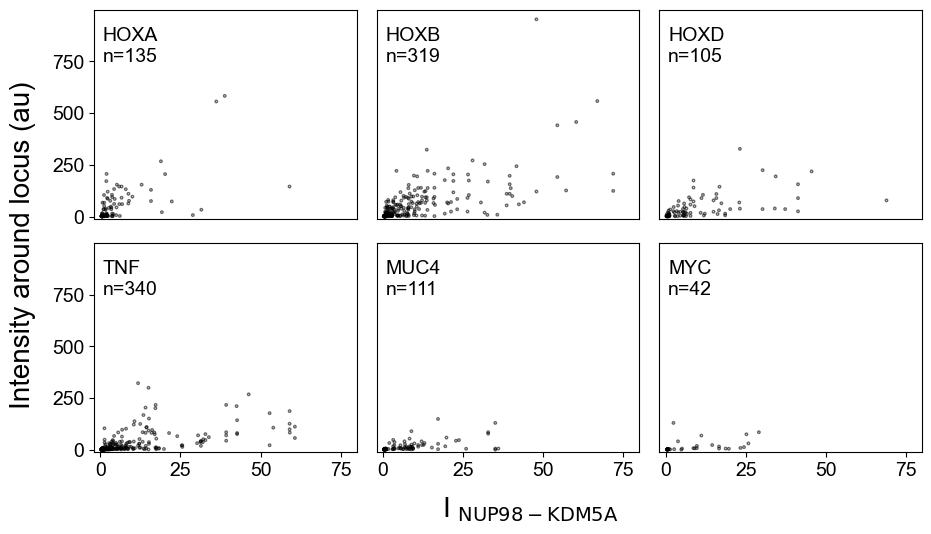

In [20]:
# 200nm scatter plot - 800nm 20th percentile

fig, axes = plt.subplots(2, 3, figsize=(9, 5))
axes = axes.flatten()

# Add a labels for the entire figure
#fig.suptitle("Max Radial Intensity 200nm - 20th percentile point of 800nm" , fontsize=16, fontweight='normal')
fig.text(-0.03, 0.5, 'Intensity around locus (au)', va='center', rotation='vertical', fontsize=20)
fig.text(0.45, -0.03, 'I $_{\mathrm{NUP98-KDM5A}}$', va='center', rotation='horizontal', fontsize=20)

#radial difference

axes[0].scatter(meanexp_HoxA, HoxA_200-HoxA_800perc20, s = 3, color='black', facecolors='none', alpha=0.6, label=label_HoxA)
axes[0].set_ylim(-10, 1000)
axes[0].set_xlim(-2, 80)
axes[0].tick_params(axis='x', labelsize=14)
axes[0].tick_params(axis='y', labelsize=14)
axes[0].set_yticks([0, 250, 500, 750])
axes[0].set_xticks([])
axes[0].text(0.8, 750, label_HoxA, fontsize=14, color="black")

axes[1].scatter(meanexp_HoxB, HoxB_200-HoxB_800perc20, s = 3, color='black', facecolors='none', alpha=0.6, label=label_HoxB)
axes[1].set_ylim(-10, 1000)
axes[1].set_xlim(-2, 80)
axes[1].tick_params(axis='x', labelsize=14)
axes[1].tick_params(axis='y', labelsize=14)
axes[1].set_xticks([])
axes[1].set_yticks([])
axes[1].text(0.8, 750, label_HoxB, fontsize=14, color="black")

axes[2].scatter(meanexp_HoxD, HoxD_200-HoxD_800perc20, s = 3, color='black', facecolors='none', alpha=0.6, label=label_HoxD)
axes[2].set_ylim(-10, 1000)
axes[2].set_xlim(-2, 80)
axes[2].tick_params(axis='x', labelsize=14)
axes[2].tick_params(axis='y', labelsize=14)
axes[2].set_xticks([])
axes[2].set_yticks([])
axes[2].text(0.8, 750, label_HoxD, fontsize=14, color="black")

axes[3].scatter(meanexp_TNF, TNF_200-TNF_800perc20, s = 3, color='black', facecolors='none', alpha=0.6, label=label_TNF)
axes[3].set_ylim(-10, 1000)
axes[3].set_xlim(-2, 80)
axes[3].tick_params(axis='x', labelsize=14)
axes[3].tick_params(axis='y', labelsize=14)
axes[3].set_yticks([0, 250, 500, 750])
axes[3].text(0.8, 750, label_TNF, fontsize=14, color="black")

axes[4].scatter(meanexp_MUC4, MUC4_200-MUC4_800perc20, s = 3, color='black', facecolors='none', alpha=0.6, label=label_MUC4)
axes[4].set_ylim(-10, 1000)
axes[4].set_xlim(-2, 80)
axes[4].tick_params(axis='x', labelsize=14)
axes[4].tick_params(axis='y', labelsize=14)
axes[4].set_yticks([])
axes[4].text(0.8, 750, label_MUC4, fontsize=14, color="black")

axes[5].scatter(meanexp_MYC, MYC_200-MYC_800perc20, s = 3, color='black', facecolors='none', alpha=0.6, label=label_MYC)
axes[5].set_ylim(-10, 1000)
axes[5].set_xlim(-2, 80)
axes[5].tick_params(axis='x', labelsize=14)
axes[5].tick_params(axis='y', labelsize=14)
axes[5].set_yticks([])
axes[5].text(0.8, 750, label_MYC, fontsize=14, color="black")

plt.tight_layout()
plt.show()

output_radial_figure = 'D:/Augusto/PythonCode/Figure3/radial_intensity_200_800.png'
fig.savefig(output_radial_figure, dpi=300, bbox_inches='tight')

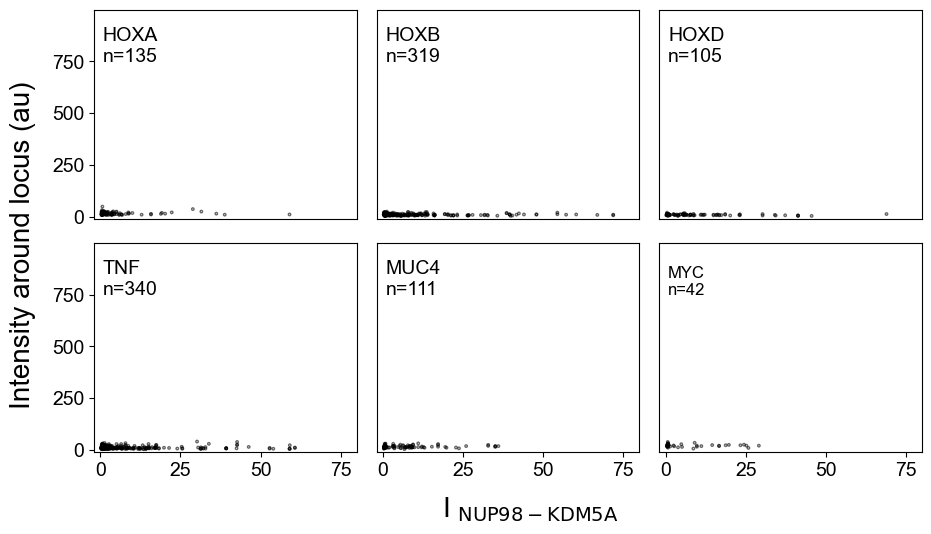

In [21]:
# 200nm scatter plot - 800nm 20th percentile - DAPI control

# 200nm scatter plot - 800nm 20th percentile

fig, axes = plt.subplots(2, 3, figsize=(9, 5))
axes = axes.flatten()

# Add a labels for the entire figure
#fig.suptitle("Max Radial Intensity 200nm - 20th percentile point of 800nm" , fontsize=16, fontweight='normal')
fig.text(-0.03, 0.5, 'Intensity around locus (au)', va='center', rotation='vertical', fontsize=20)
fig.text(0.45, -0.03, 'I $_{\mathrm{NUP98-KDM5A}}$', va='center', rotation='horizontal', fontsize=20)

#radial difference

axes[0].scatter(meanexp_HoxA_dapi, HoxA_200_dapi-HoxA_800perc20_dapi, s = 3, color='black', facecolors='none', alpha=0.6, label=label_HoxA)
axes[0].set_ylim(-10, 1000)
axes[0].set_xlim(-2, 80)
axes[0].tick_params(axis='x', labelsize=14)
axes[0].tick_params(axis='y', labelsize=14)
axes[0].set_yticks([0, 250, 500, 750])
axes[0].set_xticks([])
axes[0].text(0.8, 750, label_HoxA, fontsize=14, color="black")

axes[1].scatter(meanexp_HoxB_dapi, HoxB_200_dapi-HoxB_800perc20_dapi, s = 3, color='black', facecolors='none', alpha=0.6, label=label_HoxB)
axes[1].set_ylim(-10, 1000)
axes[1].set_xlim(-2, 80)
axes[1].tick_params(axis='x', labelsize=14)
axes[1].tick_params(axis='y', labelsize=14)
axes[1].set_xticks([])
axes[1].set_yticks([])
axes[1].text(0.8, 750, label_HoxB, fontsize=14, color="black")

axes[2].scatter(meanexp_HoxD_dapi, HoxD_200_dapi-HoxD_800perc20_dapi, s = 3, color='black', facecolors='none', alpha=0.6, label=label_HoxD)
axes[2].set_ylim(-10, 1000)
axes[2].set_xlim(-2, 80)
axes[2].tick_params(axis='x', labelsize=14)
axes[2].tick_params(axis='y', labelsize=14)
axes[2].set_xticks([])
axes[2].set_yticks([])
axes[2].text(0.8, 750, label_HoxD, fontsize=14, color="black")

axes[3].scatter(meanexp_TNF_dapi, TNF_200_dapi-TNF_800perc20_dapi, s = 3, color='black', facecolors='none', alpha=0.6, label=label_TNF)
axes[3].set_ylim(-10, 1000)
axes[3].set_xlim(-2, 80)
axes[3].tick_params(axis='x', labelsize=14)
axes[3].tick_params(axis='y', labelsize=14)
axes[3].set_yticks([0, 250, 500, 750])
axes[3].text(0.8, 750, label_TNF, fontsize=14, color="black")

axes[4].scatter(meanexp_MUC4_dapi, MUC4_200_dapi-MUC4_800perc20_dapi, s = 3, color='black', facecolors='none', alpha=0.6, label=label_MUC4)
axes[4].set_ylim(-10, 1000)
axes[4].set_xlim(-2, 80)
axes[4].tick_params(axis='x', labelsize=14)
axes[4].tick_params(axis='y', labelsize=14)
axes[4].set_yticks([])
axes[4].text(0.8, 750, label_MUC4, fontsize=14, color="black")

axes[5].scatter(meanexp_MYC_dapi, MYC_200_dapi-MYC_800perc20_dapi, s = 3, color='black', facecolors='none', alpha=0.6, label=label_MYC)
axes[5].set_ylim(-10, 1000)
axes[5].set_xlim(-2, 80)
axes[5].tick_params(axis='x', labelsize=14)
axes[5].tick_params(axis='y', labelsize=14)
axes[5].set_yticks([])
axes[5].text(0.8, 750, label_MYC, fontsize=12, color="black")

plt.tight_layout()
plt.show()

output_radial_figure = 'D:/Augusto/PythonCode/FigureS3/radial_intensity_dapi_200_800.png'
fig.savefig(output_radial_figure, dpi=300, bbox_inches='tight')


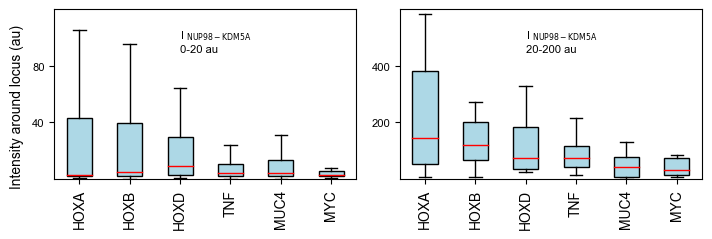

In [22]:
# 200nm scatter plot - 800nm 20th percentile - boxplots

exp_bins = np.array([0, 20, 200])  # bins: [0–10], [10–20], [20-200]

indices_in_bins_HoxA = expressionBins(meanexp_HoxA, exp_bins)
indices_in_bins_HoxB = expressionBins(meanexp_HoxB, exp_bins)
indices_in_bins_HoxD = expressionBins(meanexp_HoxD, exp_bins)

indices_in_bins_TNF = expressionBins(meanexp_TNF, exp_bins)
indices_in_bins_MUC4 = expressionBins(meanexp_MUC4, exp_bins)
indices_in_bins_MYC = expressionBins(meanexp_MYC, exp_bins)

HoxA_elip = HoxA_200-HoxA_800perc20
HoxB_elip = HoxB_200-HoxB_800perc20
HoxD_elip = HoxD_200-HoxD_800perc20

TNF_elip = TNF_200-TNF_800perc20
MUC4_elip = MUC4_200-MUC4_800perc20
MYC_elip = MYC_200-MYC_800perc20

bin_edges = '0-20', '20-200'

fig, axes = plt.subplots(1, 2, figsize=(7, 2.5))

# Add a labels for the entire figure
# fig.suptitle("Nup98-KDM5A-mEGFP binned intensity", fontsize=16, fontweight='normal')
fig.text(-0.01, 0.55, 'Intensity around locus (au)', va='center', rotation='vertical', fontsize=10)

# Flatten axes to make iteration easy
axes = axes.flatten()

for i, ax in enumerate(axes):
    
    data = [
        HoxA_elip[indices_in_bins_HoxA.get(i+1)],
        HoxB_elip[indices_in_bins_HoxB.get(i+1)],
        HoxD_elip[indices_in_bins_HoxD.get(i+1)],

        TNF_elip[indices_in_bins_TNF.get(i+1)],
        MUC4_elip[indices_in_bins_MUC4.get(i+1)],
        MYC_elip[indices_in_bins_MYC.get(i+1)],
                ]
    
    groups = ['HOXA', 'HOXB', 'HOXD',
              'TNF', 'MUC4', 'MYC']

    
    # Boxplot
    ax.boxplot(data, labels=groups, patch_artist=True,
               boxprops=dict(facecolor="lightblue", color="black"),
               medianprops=dict(color="red"),
               flierprops=dict(marker='o', markerfacecolor='black', markersize=4, linestyle='none', alpha=0.0))
    
    ax.set_xticklabels(groups, fontdict={'fontsize': 10, 'fontweight': 'normal', 'fontname': 'Arial'},
                      rotation=90, ha='center')

    ax.tick_params(axis='y', labelsize=8)  # font size for y-ticks
    
    if i == 0:
        
        ax.set_ylim(0, 120)
        ax.text(3, 90, f"I $_{{\mathrm{{NUP98-KDM5A}}}}$\n{bin_edges[i]} au", fontsize=8, color="black")
        ax.set_yticks([40, 80])
    
    if i == 1:
        ax.set_yticks([])
        
        ax.set_ylim(0, 600)
        ax.text(3, 450, f"I $_{{\mathrm{{NUP98-KDM5A}}}}$\n{bin_edges[i]} au", fontsize=8, color="black")
        ax.set_yticks([200, 400])

plt.tight_layout()
plt.show()

output_bin_figure = 'D:/Augusto/PythonCode/Figure3/binned_intensities_200_800.png'
fig.savefig(output_bin_figure, dpi=300, bbox_inches='tight')
    

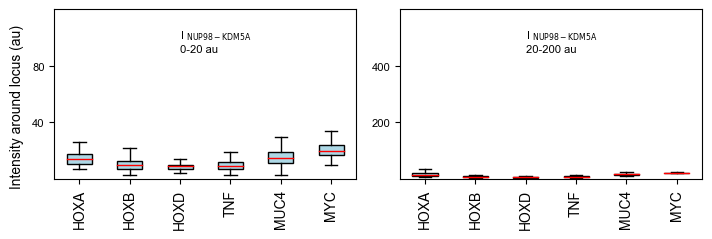

In [23]:
# 200nm scatter plot - 800nm 20th percentile - boxplots - DAPI

exp_bins = np.array([0, 20, 200])  # bins: [0–10], [10–20], [20-200]

indices_in_bins_HoxA = expressionBins(meanexp_HoxA_dapi, exp_bins)
indices_in_bins_HoxB = expressionBins(meanexp_HoxB_dapi, exp_bins)
indices_in_bins_HoxD = expressionBins(meanexp_HoxD_dapi, exp_bins)

indices_in_bins_TNF = expressionBins(meanexp_TNF_dapi, exp_bins)
indices_in_bins_MUC4 = expressionBins(meanexp_MUC4_dapi, exp_bins)
indices_in_bins_MYC = expressionBins(meanexp_MYC_dapi, exp_bins)

HoxA_elip = HoxA_200_dapi-HoxA_800perc20_dapi
HoxB_elip = HoxB_200_dapi-HoxB_800perc20_dapi
HoxD_elip = HoxD_200_dapi-HoxD_800perc20_dapi

TNF_elip = TNF_200_dapi-TNF_800perc20_dapi
MUC4_elip = MUC4_200_dapi-MUC4_800perc20_dapi
MYC_elip = MYC_200_dapi-MYC_800perc20_dapi

bin_edges = '0-20', '20-200'

fig, axes = plt.subplots(1, 2, figsize=(7, 2.5))

# Add a labels for the entire figure
# fig.suptitle("Nup98-KDM5A-mEGFP binned intensity", fontsize=16, fontweight='normal')
fig.text(-0.01, 0.55, 'Intensity around locus (au)', va='center', rotation='vertical', fontsize=10)

# Flatten axes to make iteration easy
axes = axes.flatten()

for i, ax in enumerate(axes):
    
    data = [
        HoxA_elip[indices_in_bins_HoxA.get(i+1)],
        HoxB_elip[indices_in_bins_HoxB.get(i+1)],
        HoxD_elip[indices_in_bins_HoxD.get(i+1)],

        TNF_elip[indices_in_bins_TNF.get(i+1)],
        MUC4_elip[indices_in_bins_MUC4.get(i+1)],
        MYC_elip[indices_in_bins_MYC.get(i+1)],
                ]
    
    groups = ['HOXA', 'HOXB', 'HOXD',
              'TNF', 'MUC4', 'MYC']

    
    # Boxplot
    ax.boxplot(data, labels=groups, patch_artist=True,
               boxprops=dict(facecolor="lightblue", color="black"),
               medianprops=dict(color="red"),
               flierprops=dict(marker='o', markerfacecolor='black', markersize=4, linestyle='none', alpha=0.0))
    
    ax.set_xticklabels(groups, fontdict={'fontsize': 10, 'fontweight': 'normal', 'fontname': 'Arial'},
                      rotation=90, ha='center')

    ax.tick_params(axis='y', labelsize=8)  # font size for y-ticks
    
    if i == 0:
        
        ax.set_ylim(0, 120)
        ax.text(3, 90, f"I $_{{\mathrm{{NUP98-KDM5A}}}}$\n{bin_edges[i]} au", fontsize=8, color="black")
        ax.set_yticks([40, 80])
    
    if i == 1:
        ax.set_yticks([])
        
        ax.set_ylim(0, 600)
        ax.text(3, 450, f"I $_{{\mathrm{{NUP98-KDM5A}}}}$\n{bin_edges[i]} au", fontsize=8, color="black")
        ax.set_yticks([200, 400])
        
plt.tight_layout()
plt.show()

output_bin_figure = 'D:/Augusto/PythonCode/FigureS3/binned_dapi_intensities_200_800.png'
fig.savefig(output_bin_figure, dpi=300, bbox_inches='tight')